# NB 43 - Observability & figure gallery (no LLM)

Pure inspection of a run produced by **NB 42** (`data/output/smoke/nb42_persuadable`). No simulation
is run here, so this notebook is fast and re-runnable.

1. **Full prompt walkthrough** - for one sampled agent, print the exact `system_prompt`,
   `user_prompt` and `response` for every stage in order (`agent_prompts.csv`).
2. **Figure gallery** - render every new O2 figure and eyeball it: the Day-0 anchor marker,
   per-bucket GT lines, ridgeline, network before/after, targeting mechanism, etc.

> Run NB 42 first so the run directory exists.

## 1. Load the NB 42 run

In [1]:
import os, sys, json
from pathlib import Path

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))

import pandas as pd
from IPython.display import Image, display

RUN = Path('../data/output/smoke/nb42_persuadable')
assert RUN.exists(), f'Run dir not found: {RUN}. Run NB 42 first.'

cfg = json.loads((RUN / 'config.json').read_text())
print('day0_anchor      :', cfg.get('day0_anchor'))
print('memory           :', cfg.get('memory'))
print('reach_a          :', cfg.get('reach_a'), '| reach_targeting_a:', cfg.get('reach_targeting_a'))
print('files:', sorted(p.name for p in RUN.glob('*')))

day0_anchor      : ground_truth_with_rationale
memory           : {'day0_anchor': {'ttl_days': 1}}
reach_a          : 0.4 | reach_targeting_a: persuadable
files: ['agent_attributes.csv', 'agent_prompts.csv', 'agent_timeline.csv', 'bucket_summary.csv', 'calibration.csv', 'calibration_before_after.png', 'calibration_by_policy.png', 'config.json', 'daily_summaries.csv', 'day0_vs_dayN_shifts.csv', 'drift_from_gt.png', 'gap_widening.png', 'ground_truth.csv', 'message_flow.csv', 'messages.csv', 'network_before_after.png', 'network_graph.png', 'network_snapshot.json', 'opinion_ridgeline.png', 'opinion_shares.csv', 'opinion_shares.png', 'opinion_shares_by_bucket.csv', 'opinion_shares_by_bucket.png', 'opinion_trajectories.csv', 'opinion_trajectories.png', 'opinion_trajectories_by_bucket.png', 'package_ground_truth.csv', 'package_index_by_bucket.csv', 'package_index_by_bucket.png', 'package_index_shares.csv', 'package_index_shares.png', 'package_index_trajectories.csv', 'package_index_trajectori

## 2. Full prompt walkthrough (one sampled agent)

Everything the agent actually saw, stage by stage, in `prompt_seq` order.

In [2]:
ap = pd.read_csv(RUN / 'agent_prompts.csv')
print('sampled agents:', sorted(ap['agent_id'].unique()))

agent = ap['agent_id'].iloc[0]
one = ap[ap['agent_id'] == agent].sort_values('prompt_seq')
print(f'\nAgent {agent}: {len(one)} captured LLM calls across stages '
      f"{sorted(one['stage'].unique())}\n")
display(one[['prompt_seq', 'day', 'phase', 'stage', 'policy_id']])

sampled agents: [np.float64(103.0), np.float64(355.0), np.float64(620.0), np.float64(1001.0)]

Agent 103.0: 48 captured LLM calls across stages ['peer_message', 'reflection_peer', 'seed_rationale', 'survey_answer', 'survey_reasoning']



,prompt_seq,day,phase,stage,policy_id
0,0,0,NaN,seed_rationale,ClimatePolicyID(1)
1,1,0,NaN,seed_rationale,ClimatePolicyID(2)
2,2,0,NaN,seed_rationale,ClimatePolicyID(3)
3,3,0,NaN,seed_rationale,ClimatePolicyID(4)
4,4,0,NaN,seed_rationale,ClimatePolicyID(5)
5,5,0,NaN,seed_rationale,ClimatePolicyID(6)
6,6,1,C,peer_message,climate_policy_package
7,7,1,C,reflection_peer,climate_policy_package
8,8,1,survey,survey_reasoning,ClimatePolicyID(3)
9,9,1,survey,survey_answer,ClimatePolicyID(3)


In [3]:
def show_prompt(rowlike, n_sys=1400, n_usr=800, n_resp=800):
    print('=' * 100)
    print(f"[seq {rowlike['prompt_seq']}]  day={rowlike['day']}  phase={rowlike['phase']}  "
          f"stage={rowlike['stage']}  policy={rowlike['policy_id']}")
    print('-' * 100)
    print('SYSTEM PROMPT:\n' + str(rowlike['system_prompt'])[:n_sys])
    print('\nUSER PROMPT:\n' + str(rowlike['user_prompt'])[:n_usr])
    print('\nRESPONSE:\n' + str(rowlike['response'])[:n_resp])
    print()


for stage in ['seed_rationale', 'survey_reasoning', 'survey_answer',
              'reflection_broadcast', 'reflection_peer', 'peer_message']:
    sub = one[one['stage'] == stage]
    if not sub.empty:
        show_prompt(sub.iloc[0])

[seq 0]  day=0  phase=nan  stage=seed_rationale  policy=ClimatePolicyID(1)
----------------------------------------------------------------------------------------------------
SYSTEM PROMPT:
I am a 49 year old male living in the East of England. My ethnicity is mixed. I have a CSE grade 1, GCE O level, GCSE, School Certificate. My gross household income is £100,000 - £149,999 per year. I am a parent. I position myself slightly left-of-centre of the political spectrum. I voted for the Labour party candidate in the 2019 General Election. I voted to leave in the 2016 EU Referendum.
When it comes to my core values and worldview: I am deeply committed to caring for nature, protecting the environment, and responding to the needs of others. I strongly believe in global harmony, equal opportunities for everyone, and actively helping those around me. I appreciate personal success and am capable of taking charge when necessary, but I do not feel a constant need to dominate decisions or impress o

### How the assembled context evolves day-to-day

For the survey stage, compare the `system_prompt` length across days for this agent - it should grow
as daily summaries / reflections accumulate, and the Day-0 anchor should drop out after Day 1
(`ttl_days=1`).

In [4]:
surv = one[one['stage'] == 'survey_answer'].copy()
surv['sys_chars'] = surv['system_prompt'].astype(str).str.len()
surv['mentions_anchor'] = surv['system_prompt'].astype(str).str.contains('anchor|considered position|Day 0', case=False)
display(surv[['prompt_seq', 'day', 'policy_id', 'sys_chars', 'mentions_anchor']])

,prompt_seq,day,policy_id,sys_chars,mentions_anchor
9,9,1,ClimatePolicyID(3),4632,False
11,11,1,ClimatePolicyID(5),5374,False
13,13,1,ClimatePolicyID(4),6194,False
15,15,1,ClimatePolicyID(1),6659,False
17,17,1,ClimatePolicyID(2),7569,False
19,19,1,ClimatePolicyID(6),8169,False
23,23,2,ClimatePolicyID(1),6315,True
25,25,2,ClimatePolicyID(3),6817,True
27,27,2,ClimatePolicyID(4),7852,True
29,29,2,ClimatePolicyID(5),8393,True


## 3. Figure gallery

Every O2 figure saved by the run. Eyeball: Day-0 GT-anchor diamond (not connected to the line),
per-bucket GT reference lines, ridgeline distribution shift, and the reached-node rings in the
network panels.


### package_index_trajectories.png


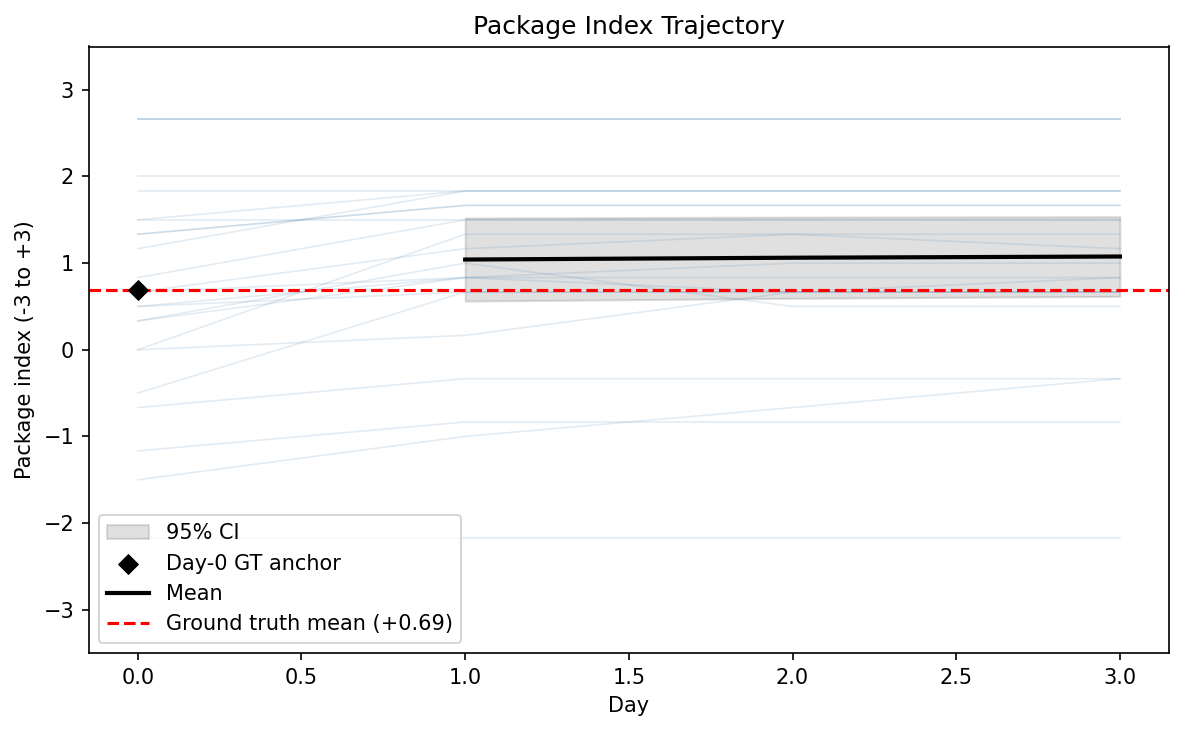


### package_index_by_bucket.png


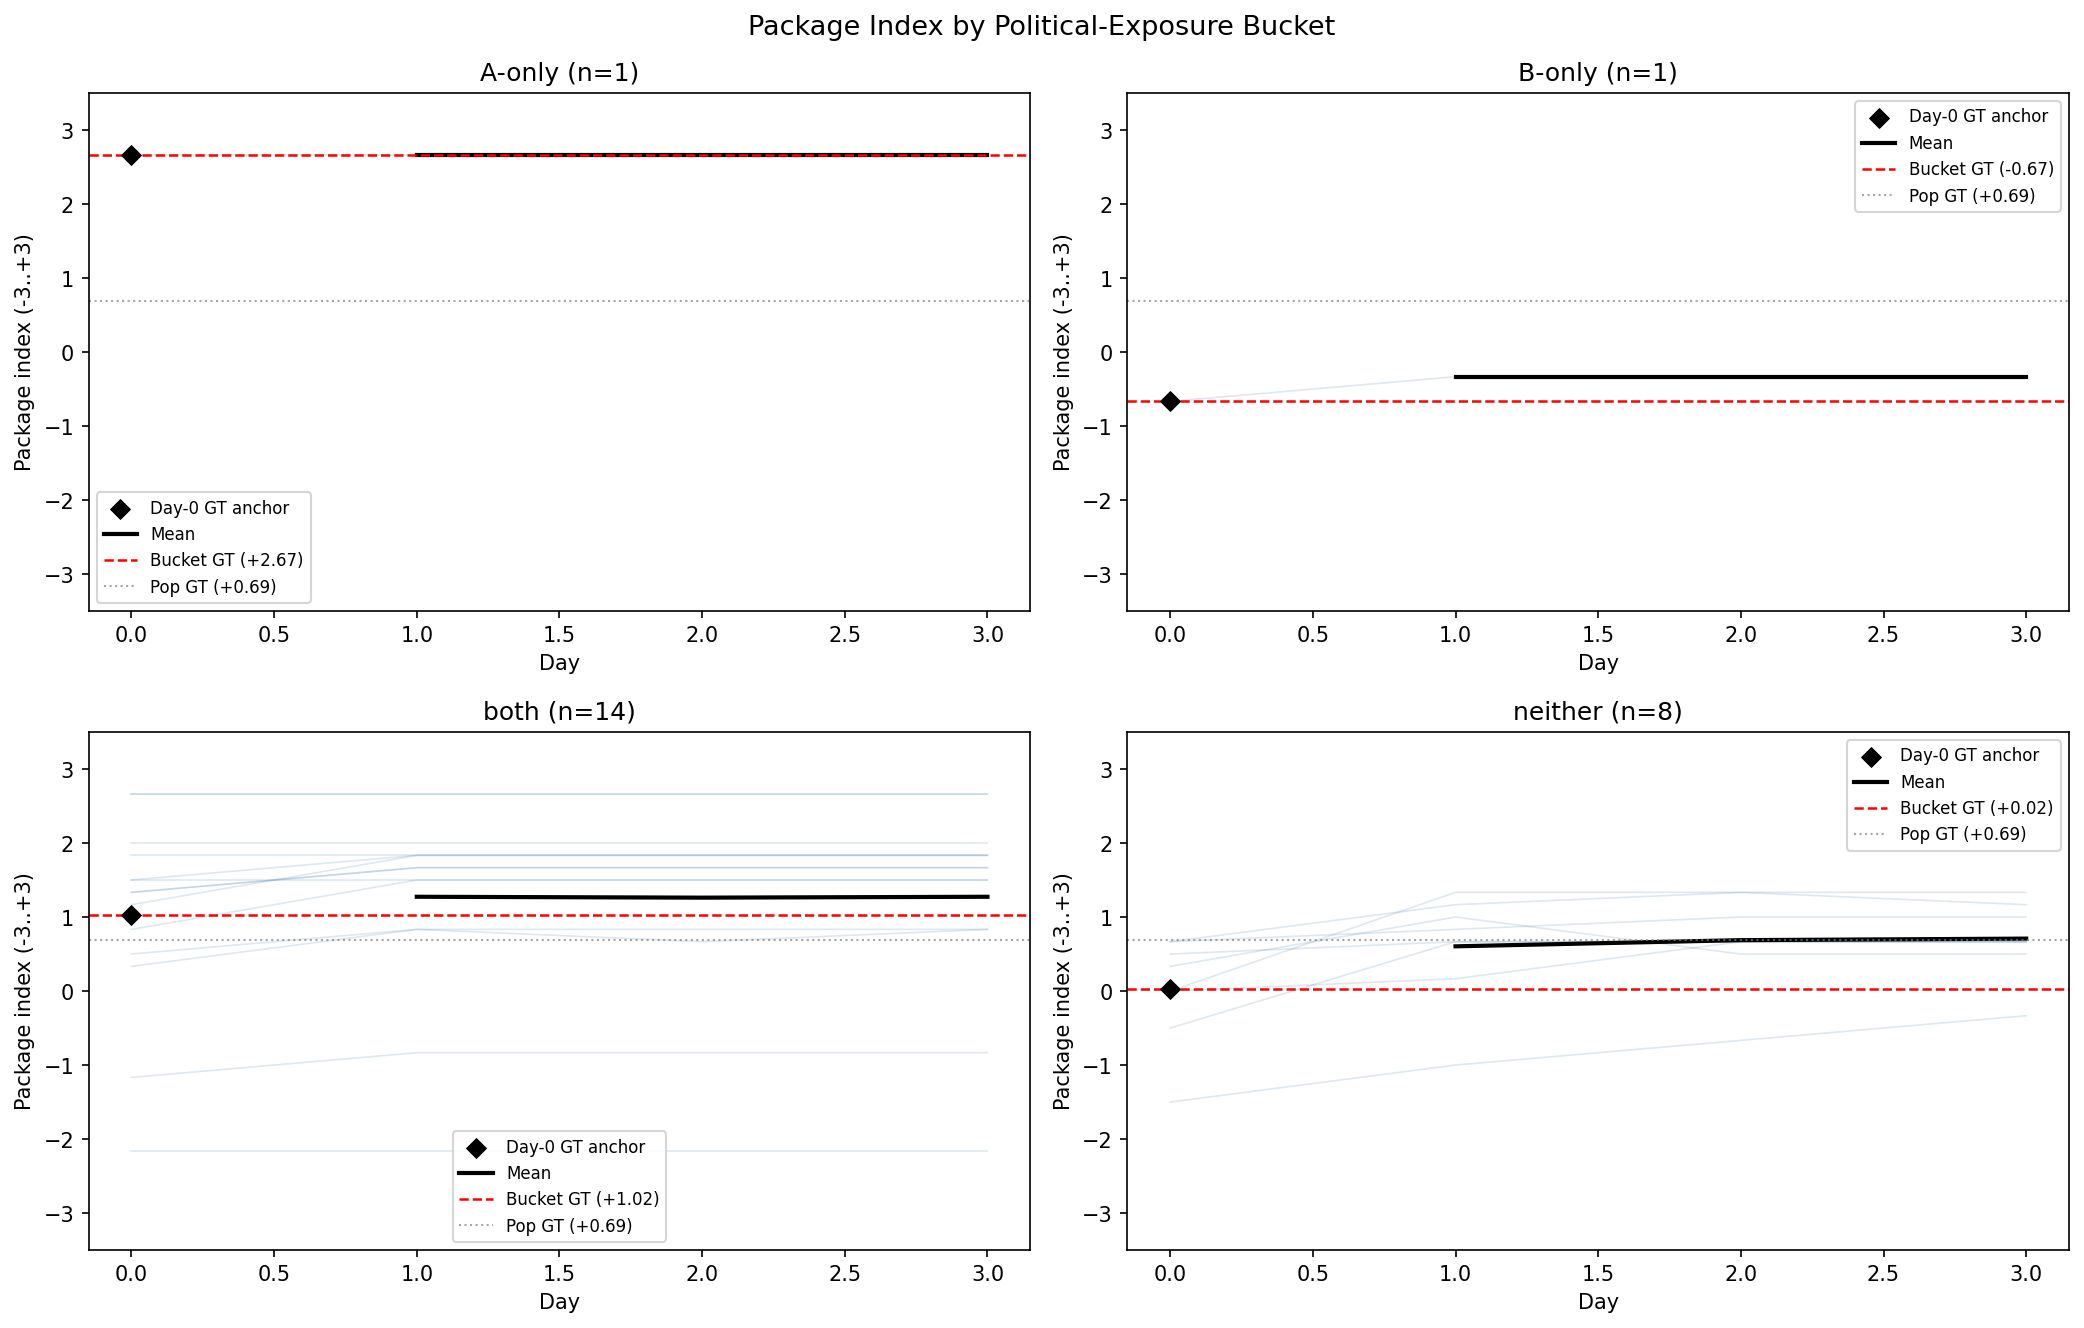


### opinion_trajectories_by_bucket.png


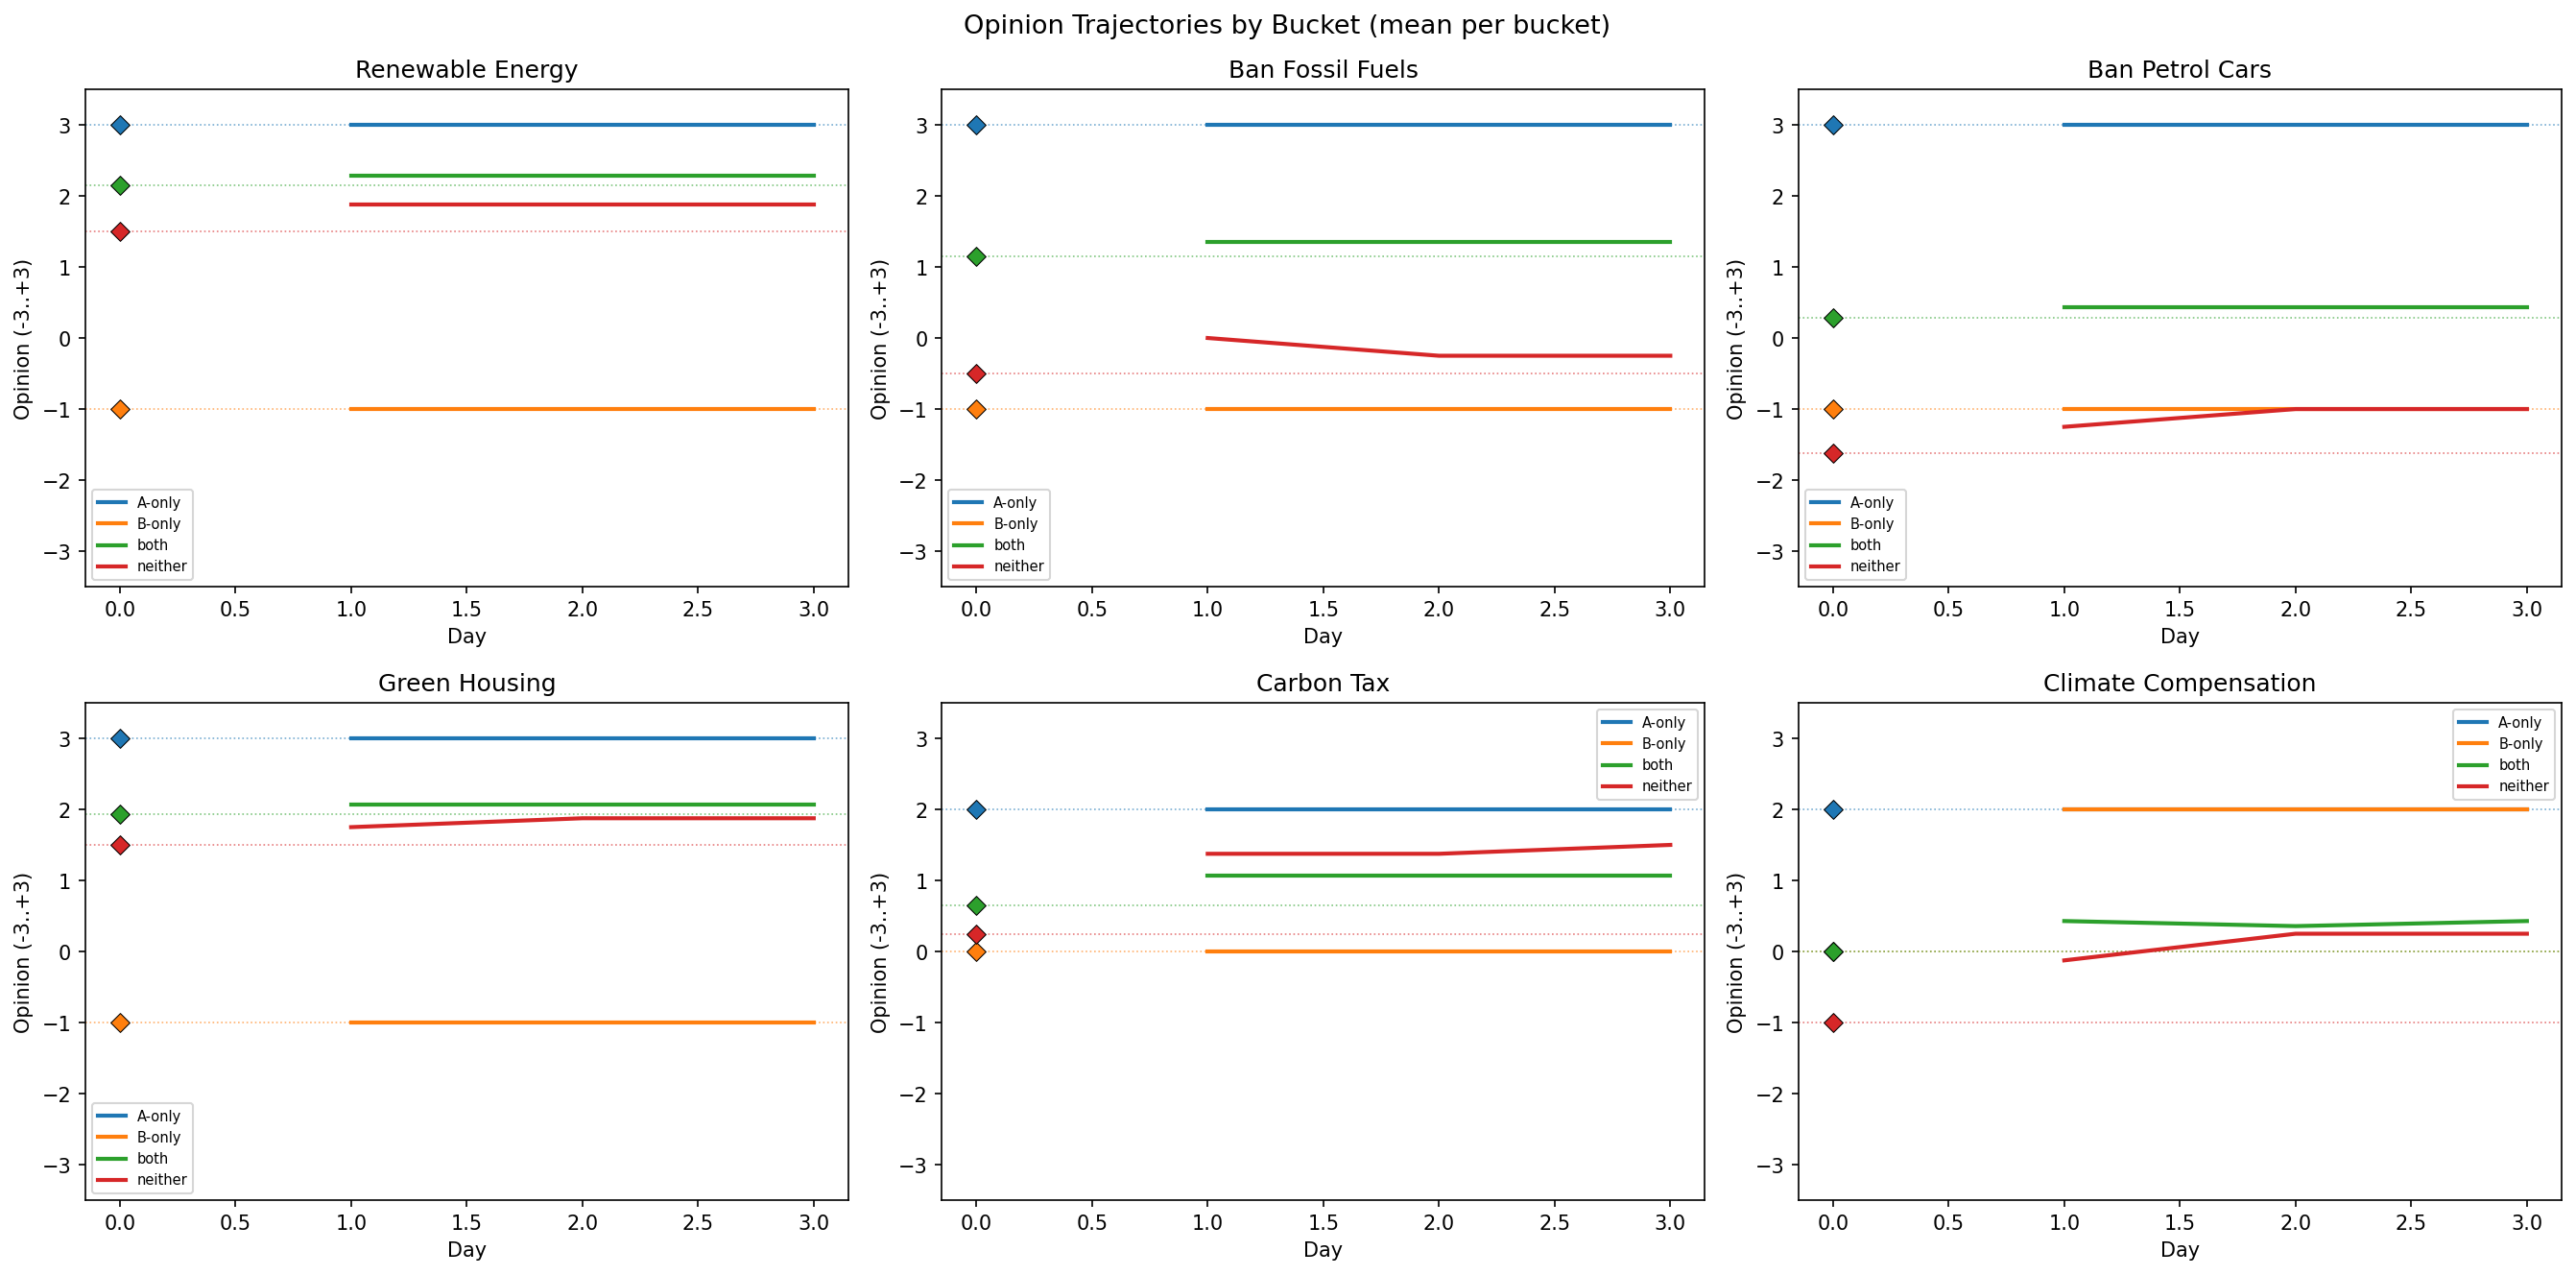


### opinion_ridgeline.png


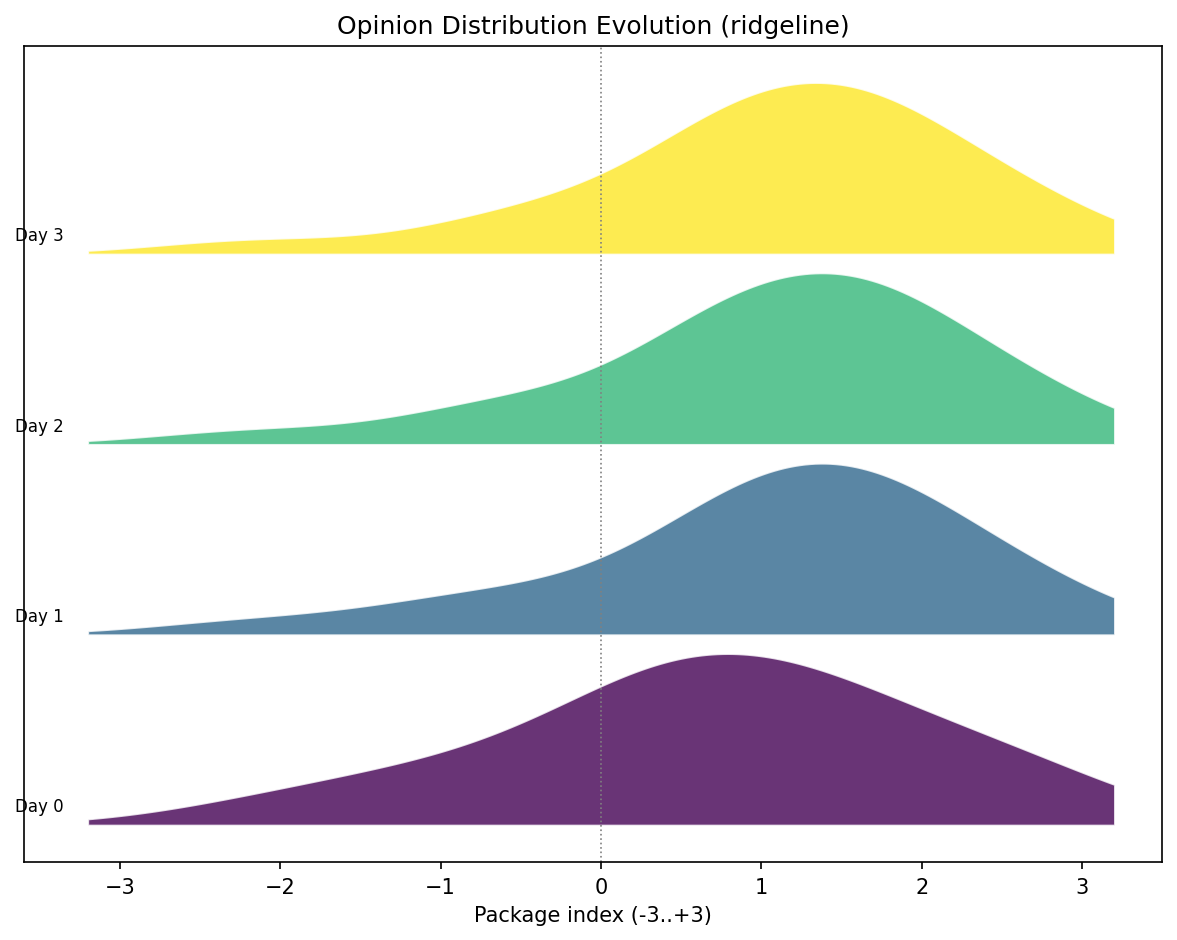


### network_before_after.png


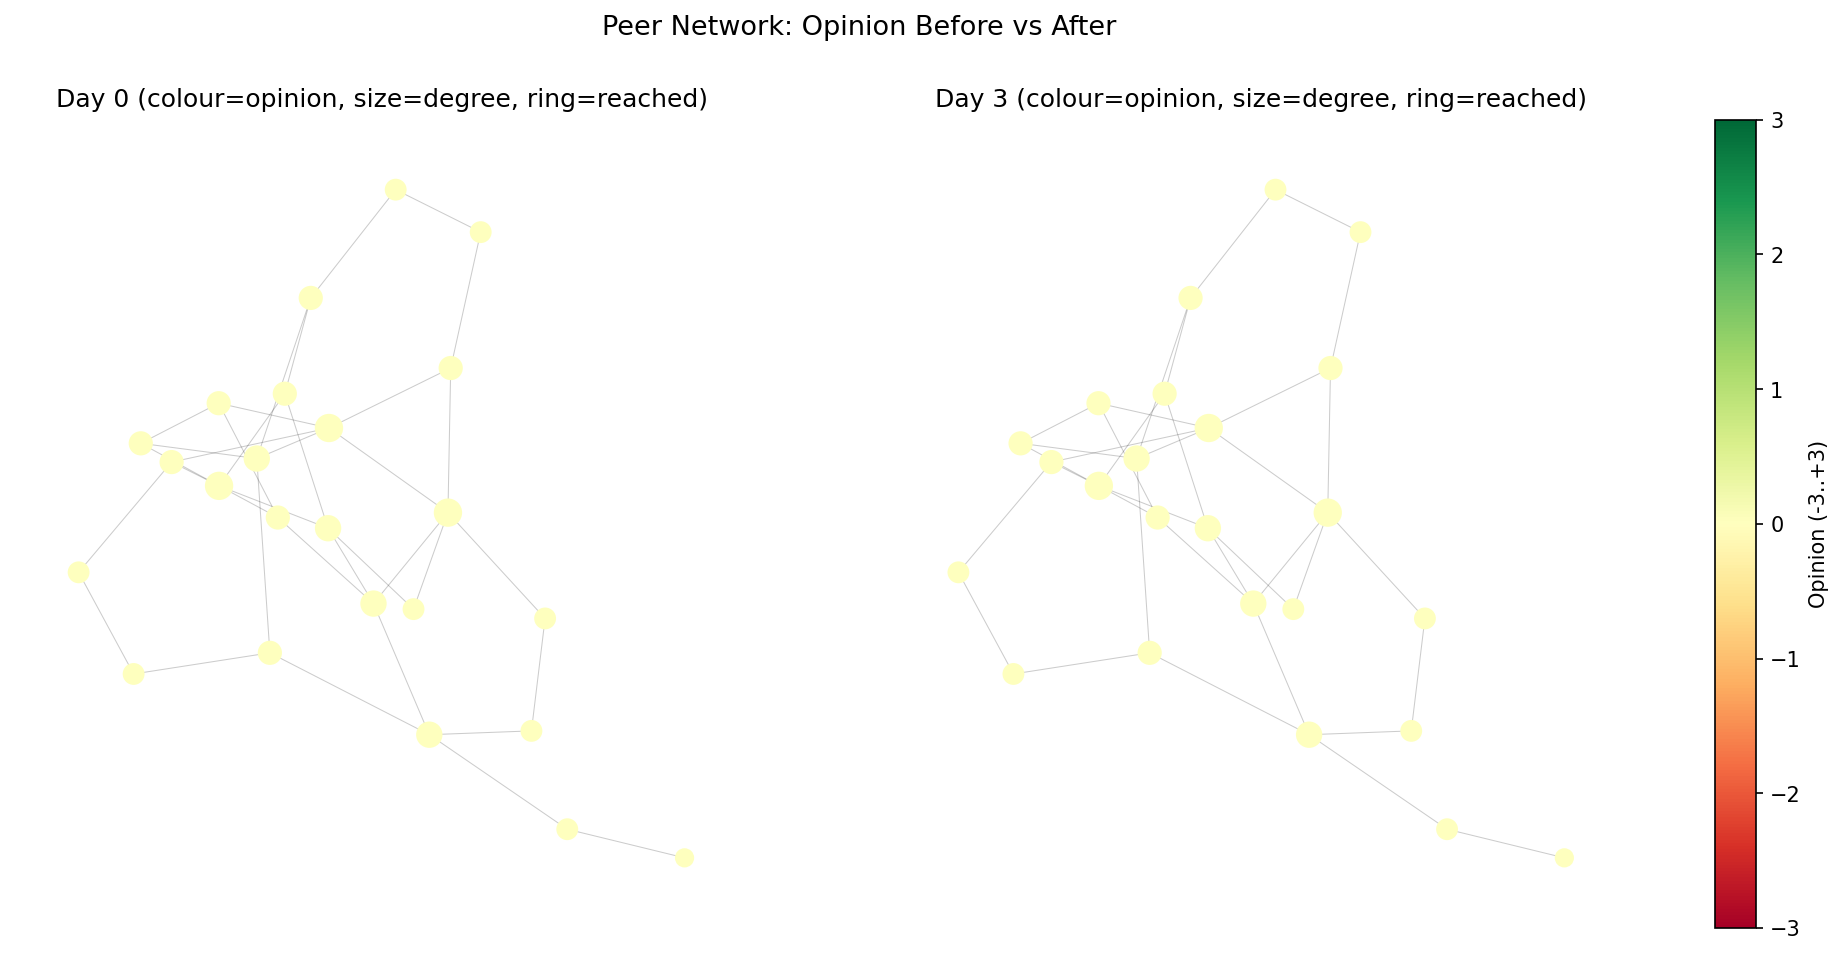


### drift_from_gt.png


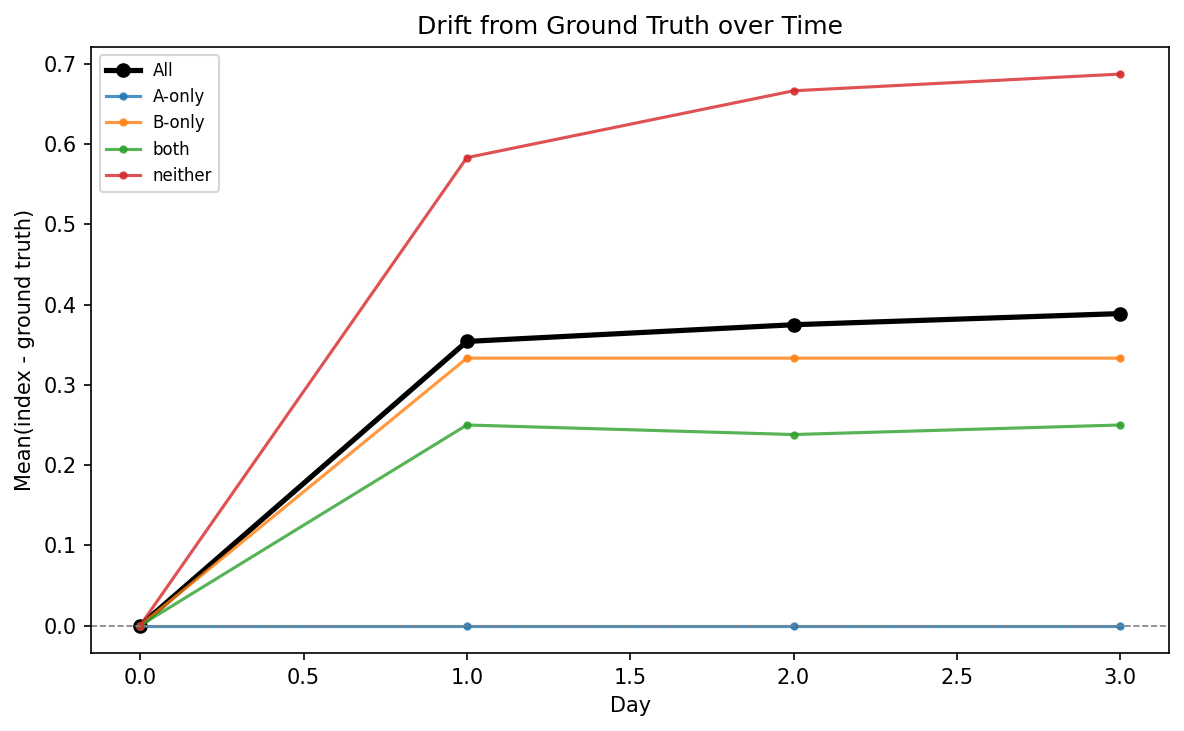


### polarization.png


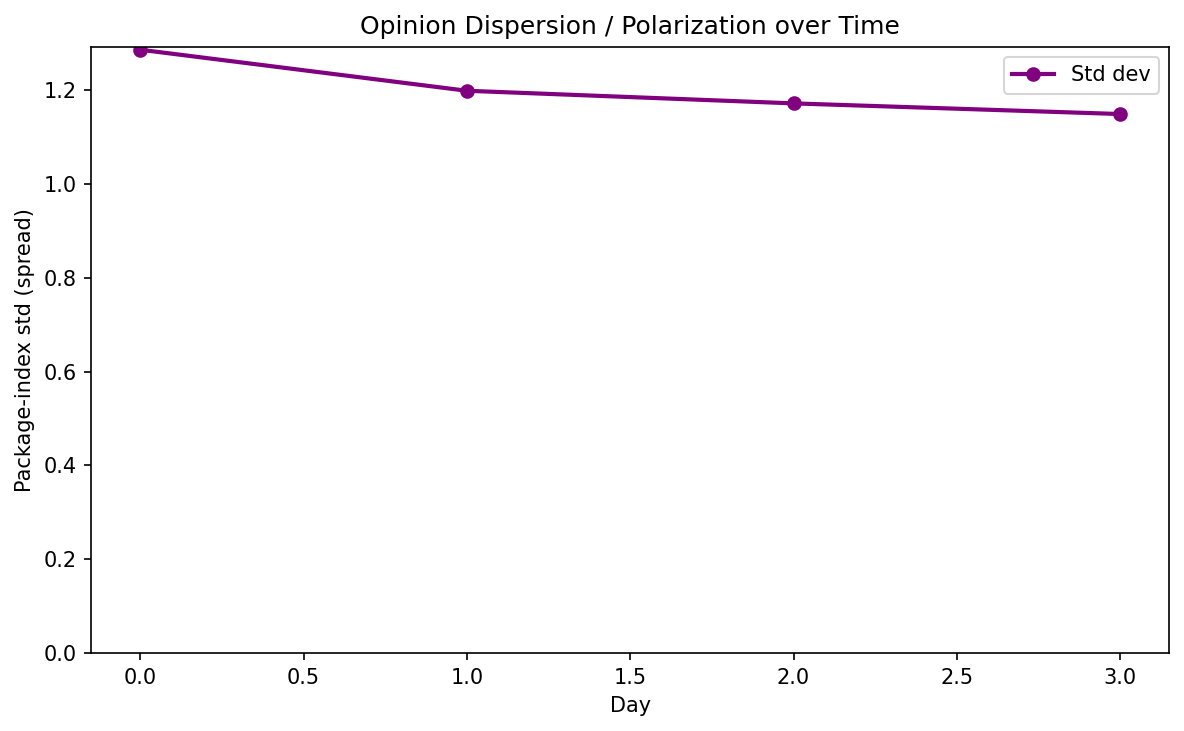


### targeting_mechanism.png


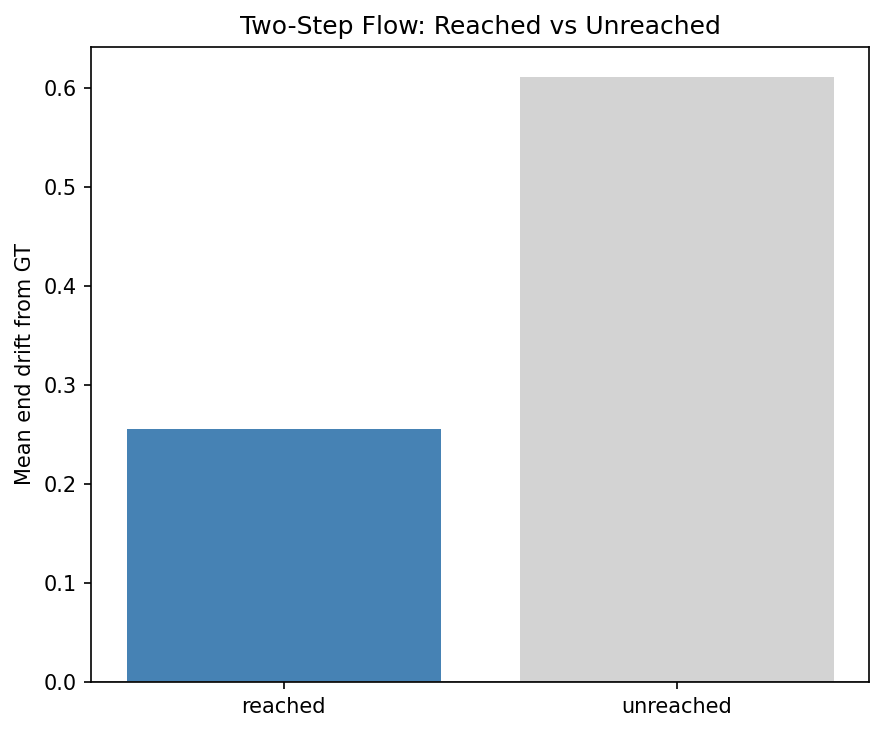


### reach_qc.png


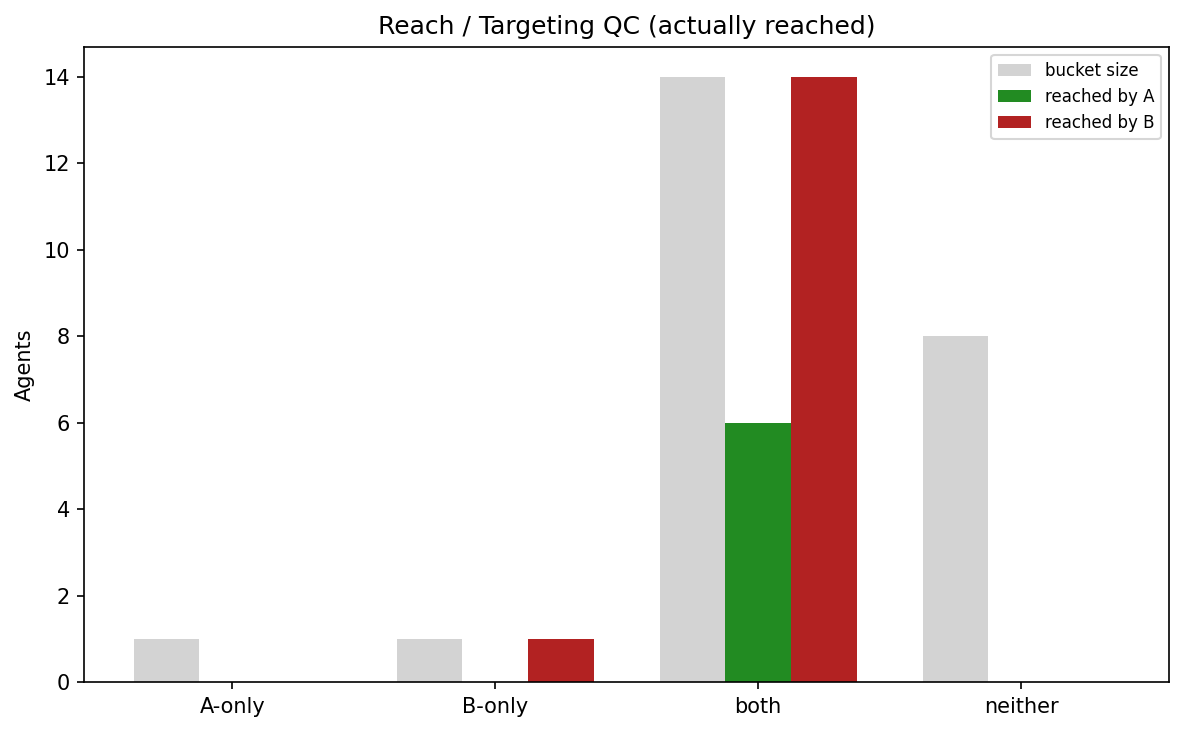


### calibration_before_after.png


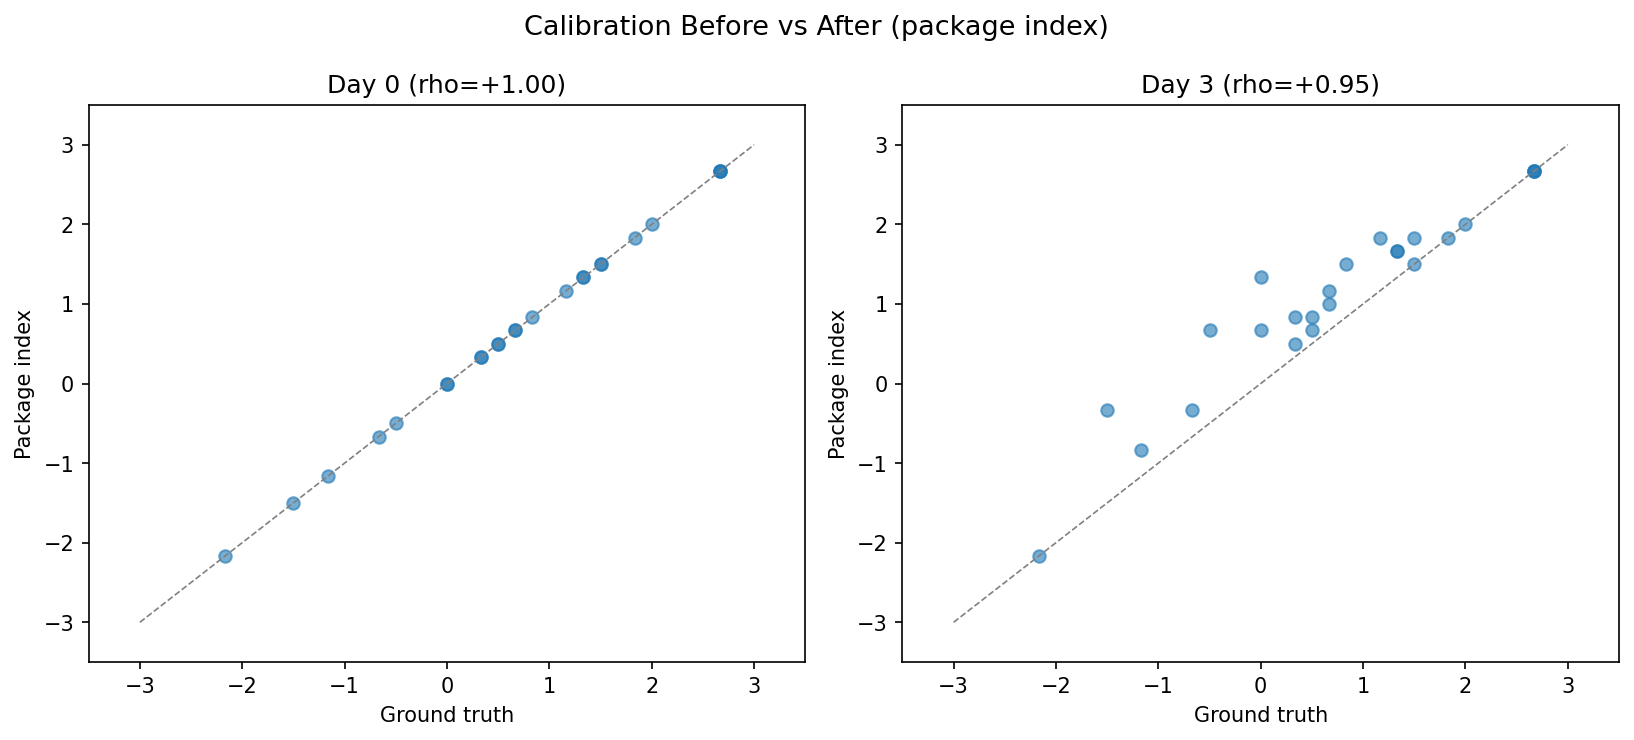

In [5]:
gallery = [
    'package_index_trajectories.png',
    'package_index_by_bucket.png',
    'opinion_trajectories_by_bucket.png',
    'opinion_ridgeline.png',
    'network_before_after.png',
    'drift_from_gt.png',
    'polarization.png',
    'targeting_mechanism.png',
    'reach_qc.png',
    'calibration_before_after.png',
]
for name in gallery:
    p = RUN / name
    if p.exists():
        print(f'\n### {name}')
        display(Image(filename=str(p)))
    else:
        print(f'(missing: {name})')

## 4. Summary

If the prompt walkthrough shows all six stages with coherent persona-grounded context, and the
gallery renders with the Day-0 anchor as a separate marker + per-bucket GT lines, the O1/O2
observability layer is verified. Next: docs pass -> base-size presets -> sweep files.